# Telco Customer Churn Prediction
### AI/Machine Learning Project — Google Colab Notebook

**Problem:** Predict which telecom customers will cancel their subscription (churn), enabling
the business to intervene proactively with retention offers

**Why this matters:** Acquiring a new customer costs 5–25× more than retaining an existing one.
A churn prediction model that identifies at-risk customers even one month early can save millions
in lost revenue. At 26.5% annual churn, the dataset represents a real-world class-imbalance
challenge, standard accuracy is misleading (a model predicting "nobody churns" gets 73.5%),
so we optimise for ROC-AUC and F1

**Dataset:** [IBM Telco Customer Churn](https://github.com/IBM/telco-customer-churn-on-icp4d)
— 7,043 customers × 20 features (contract type, services, billing info, tenure, charges).

---

### Sections
| # | Section
|---|---|
| 1 | Problem & Dataset
| 2 | EDA
| 3 | Preprocessing
| 4 | Model Selection
| 5 | Hyperparameter Tuning
| 6 | Evaluation
| 7 | Feature Importance
| 8 | Deployment Demo


##Setup & Imports

In [1]:
!pip install imbalanced-learn -q

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, cross_val_score,
    StratifiedKFold, RandomizedSearchCV
)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, precision_recall_curve,
    average_precision_score, confusion_matrix, classification_report
)
from imblearn.over_sampling import SMOTE

np.random.seed(42)
print("✓ All libraries imported successfully")
print(f"  numpy: {np.__version__}")
print(f"  pandas: {pd.__version__}")

✓ All libraries imported successfully
  numpy: 2.0.2
  pandas: 2.2.2


## 1. Problem Definition & Dataset

### Business Context

Customer churn: when a subscriber cancels their service — is the #1 revenue leakage problem
for telecom companies. This dataset from IBM contains billing and service records for 7,043
customers of a fictional California telecom provider. Each row represents one customer;
the target column (`Churn`) indicates whether they left within the last month

**Key business questions we'll answer:**
- Which customers are at highest risk of churning?
- Which contract types and service configurations correlate with churn?
- Can we build a model accurate enough to deploy for proactive retention?

### Load the Dataset

In [3]:
# Load directly from GitHub (public domain dataset)
URL = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(URL)

print(f"Dataset shape: {df.shape}")
print(f"\nFeatures ({df.shape[1]-1} input + 1 target):")
for col in df.columns:
    print(f"  {col:25s} {df[col].dtype}")

Dataset shape: (7043, 21)

Features (20 input + 1 target):
  customerID                object
  gender                    object
  SeniorCitizen             int64
  Partner                   object
  Dependents                object
  tenure                    int64
  PhoneService              object
  MultipleLines             object
  InternetService           object
  OnlineSecurity            object
  OnlineBackup              object
  DeviceProtection          object
  TechSupport               object
  StreamingTV               object
  StreamingMovies           object
  Contract                  object
  PaperlessBilling          object
  PaymentMethod             object
  MonthlyCharges            float64
  TotalCharges              object
  Churn                     object


In [4]:
print("Sample rows:")
df.head(3)

Sample rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


In [5]:
# Check for missing values and data quality issues
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nTotalCharges dtype: {df['TotalCharges'].dtype}  — has spaces/empties: {(df['TotalCharges'].str.strip() == '').sum()} rows")
print(f"\nClass distribution:")
print(df["Churn"].value_counts())
print(f"\nChurn rate: {(df['Churn']=='Yes').mean()*100:.1f}%")

Missing values per column:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

TotalCharges dtype: object  — has spaces/empties: 11 rows

Class distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn rate: 26.5%


## 2. Exploratory Data Analysis (EDA)

### Class Distribution

The dataset has **26.5% churn** — a meaningful but manageable imbalance. A naive model that
predicts "No churn" for everyone would score 73.5% accuracy but be completely useless. We'll
address this with SMOTE oversampling and optimise for AUC/F1 instead of raw accuracy

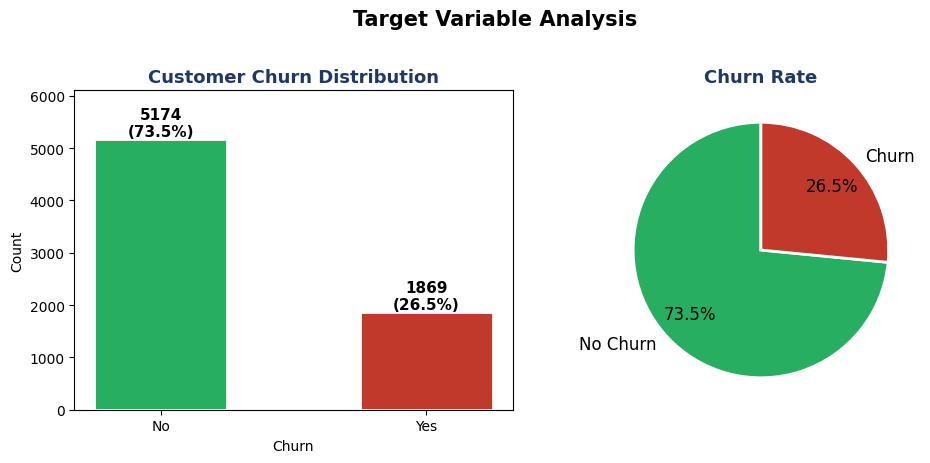

In [6]:
churn_counts = df["Churn"].value_counts()
churn_pct    = df["Churn"].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
colors = ["#27AE60", "#C0392B"]

# Bar chart
bars = axes[0].bar(churn_counts.index, churn_counts.values, color=colors, width=0.5, edgecolor="white", lw=2)
axes[0].set_title("Customer Churn Distribution", fontsize=13, fontweight="bold", color="#1F3864")
for b, (cnt, pct) in zip(bars, zip(churn_counts.values, churn_pct.values)):
    axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+50,
                 f"{cnt}\n({pct:.1f}%)", ha="center", fontsize=11, fontweight="bold")
axes[0].set_ylim(0, churn_counts.max()*1.18); axes[0].set_xlabel("Churn"); axes[0].set_ylabel("Count")

# Pie chart
axes[1].pie(churn_counts.values, labels=["No Churn","Churn"], colors=colors,
            autopct="%1.1f%%", startangle=90, wedgeprops=dict(edgecolor="white", linewidth=2),
            pctdistance=0.75, textprops={"fontsize":12})
axes[1].set_title("Churn Rate", fontsize=13, fontweight="bold", color="#1F3864")
fig.suptitle("Target Variable Analysis", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout(); plt.show()

### Numerical Feature Analysis
Customers who churn tend to have **shorter tenure**, **higher monthly charges**, and **lower total charges** (short-lived high-spend customers)

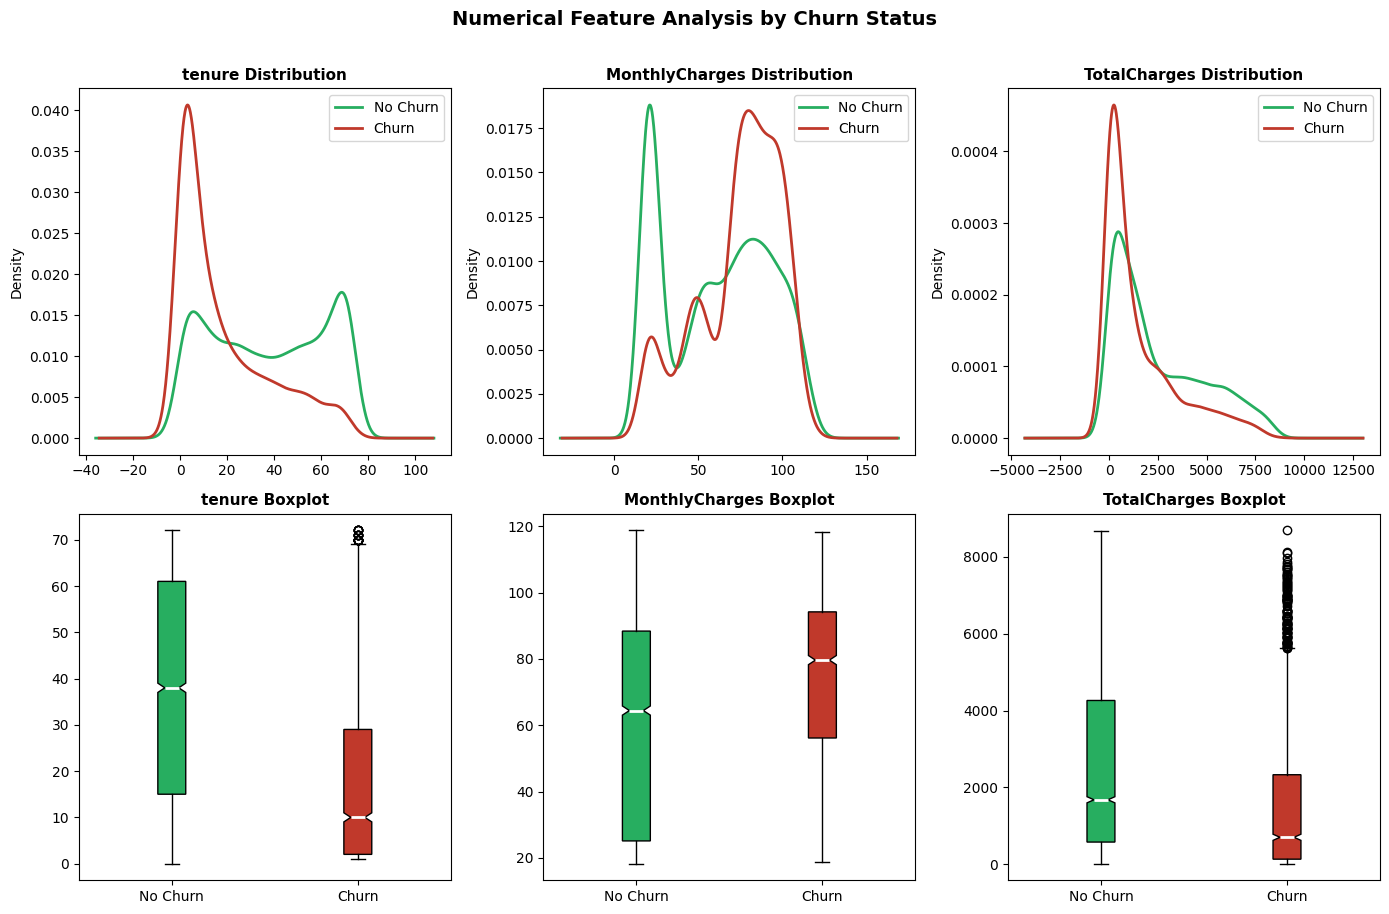

tenure                No Churn:     37.6   Churn:     18.0   Δ = -19.6
MonthlyCharges        No Churn:     61.3   Churn:     74.4   Δ = +13.2
TotalCharges          No Churn:   2552.9   Churn:   1531.8   Δ = -1021.1


In [7]:
# Fix TotalCharges type (has empty strings for new customers)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"].str.strip(), errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
palette  = {"No": "#27AE60", "Yes": "#C0392B"}

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
for i, col in enumerate(num_cols):
    # KDE distributions
    for grp, color in palette.items():
        df[df["Churn"]==grp][col].plot.kde(ax=axes[0,i], label=f"{'No Churn' if grp=='No' else 'Churn'}", color=color, lw=2)
    axes[0,i].set_title(f"{col} Distribution", fontsize=11, fontweight="bold"); axes[0,i].legend()
    # Boxplots
    bp = axes[1,i].boxplot([df[df["Churn"]=="No"][col], df[df["Churn"]=="Yes"][col]],
                            labels=["No Churn","Churn"], patch_artist=True, notch=True,
                            medianprops=dict(color="white", lw=2))
    bp["boxes"][0].set_facecolor("#27AE60"); bp["boxes"][1].set_facecolor("#C0392B")
    axes[1,i].set_title(f"{col} Boxplot", fontsize=11, fontweight="bold")

fig.suptitle("Numerical Feature Analysis by Churn Status", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout(); plt.show()

# Key stats
for col in num_cols:
    no_m  = df[df["Churn"]=="No"][col].mean()
    yes_m = df[df["Churn"]=="Yes"][col].mean()
    print(f"{col:20s}  No Churn: {no_m:8.1f}   Churn: {yes_m:8.1f}   Δ = {yes_m-no_m:+.1f}")

### Churn Rate by Categorical Feature
Key findings: **Month-to-month contracts** (42.7% churn), **Fiber optic internet** (41.9%), and **Electronic check payment** (45.3%) are the strongest categorical predictors

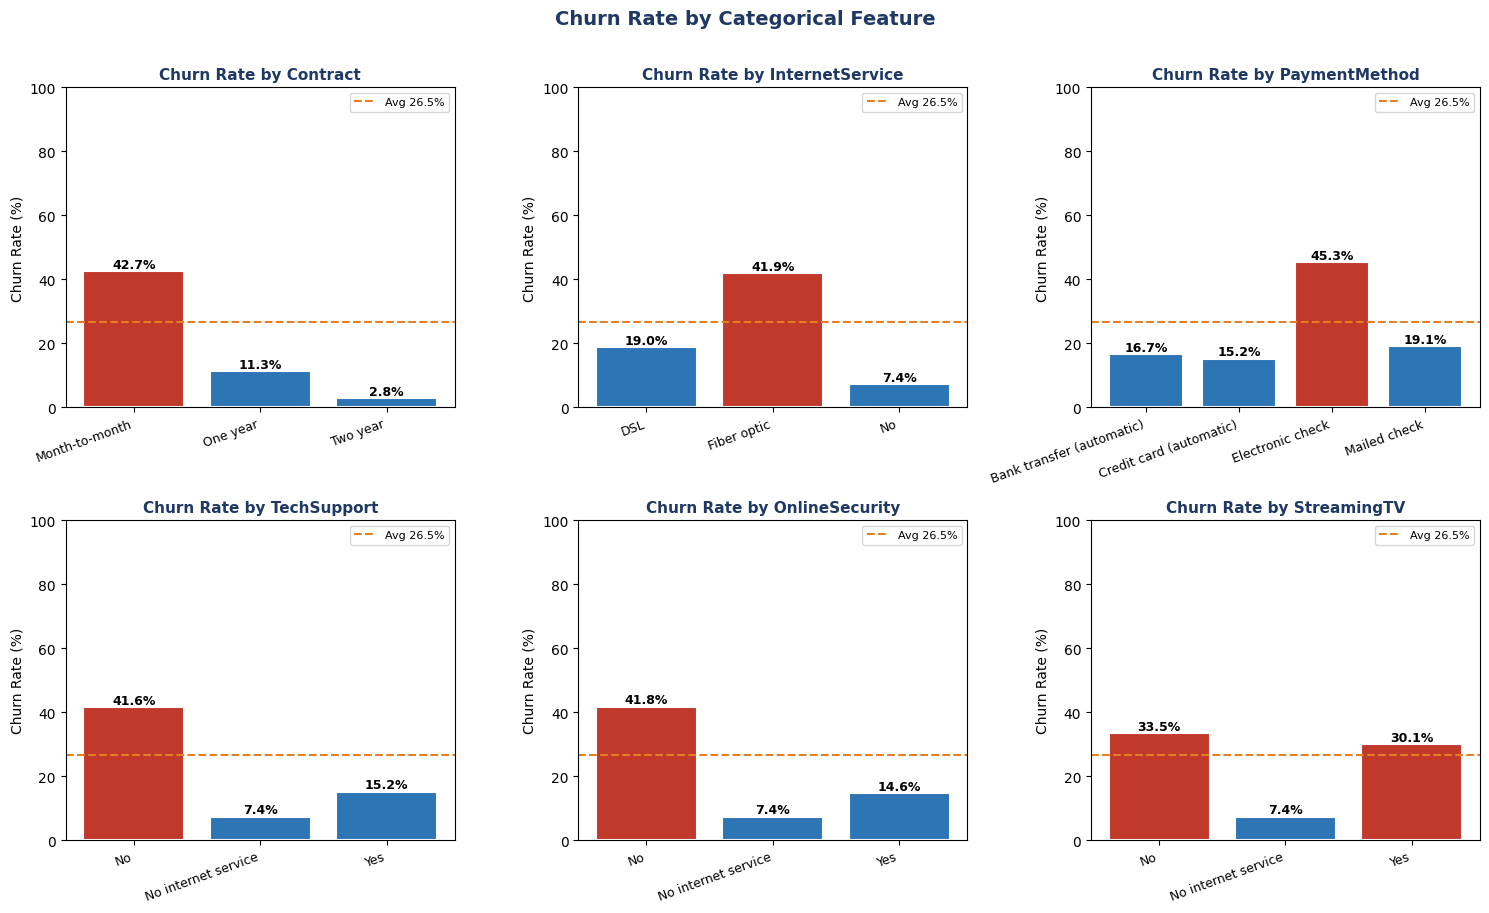

In [8]:
cat_cols_key = ["Contract","InternetService","PaymentMethod","TechSupport","OnlineSecurity","StreamingTV"]
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for ax, col in zip(axes.flatten(), cat_cols_key):
    churn_rate = df.groupby(col)["Churn"].apply(lambda x: (x=="Yes").mean()*100)
    avg = (df["Churn"]=="Yes").mean()*100
    bars = ax.bar(churn_rate.index, churn_rate.values,
                  color=["#C0392B" if v>avg else "#2E75B6" for v in churn_rate.values],
                  edgecolor="white", lw=1.5)
    ax.axhline(avg, color="#E67E22", lw=1.5, ls="--", label=f"Avg {avg:.1f}%")
    for b, v in zip(bars, churn_rate.values):
        ax.text(b.get_x()+b.get_width()/2, v+1, f"{v:.1f}%", ha="center", fontsize=9, fontweight="bold")
    ax.set_title(f"Churn Rate by {col}", fontsize=11, fontweight="bold", color="#1F3864")
    ax.set_ylabel("Churn Rate (%)"); ax.set_ylim(0,100)
    ax.legend(fontsize=8); plt.setp(ax.get_xticklabels(), rotation=20, ha="right", fontsize=9)

fig.suptitle("Churn Rate by Categorical Feature", fontsize=14, fontweight="bold", color="#1F3864", y=1.01)
plt.tight_layout(); plt.show()

### Correlation Heatmap

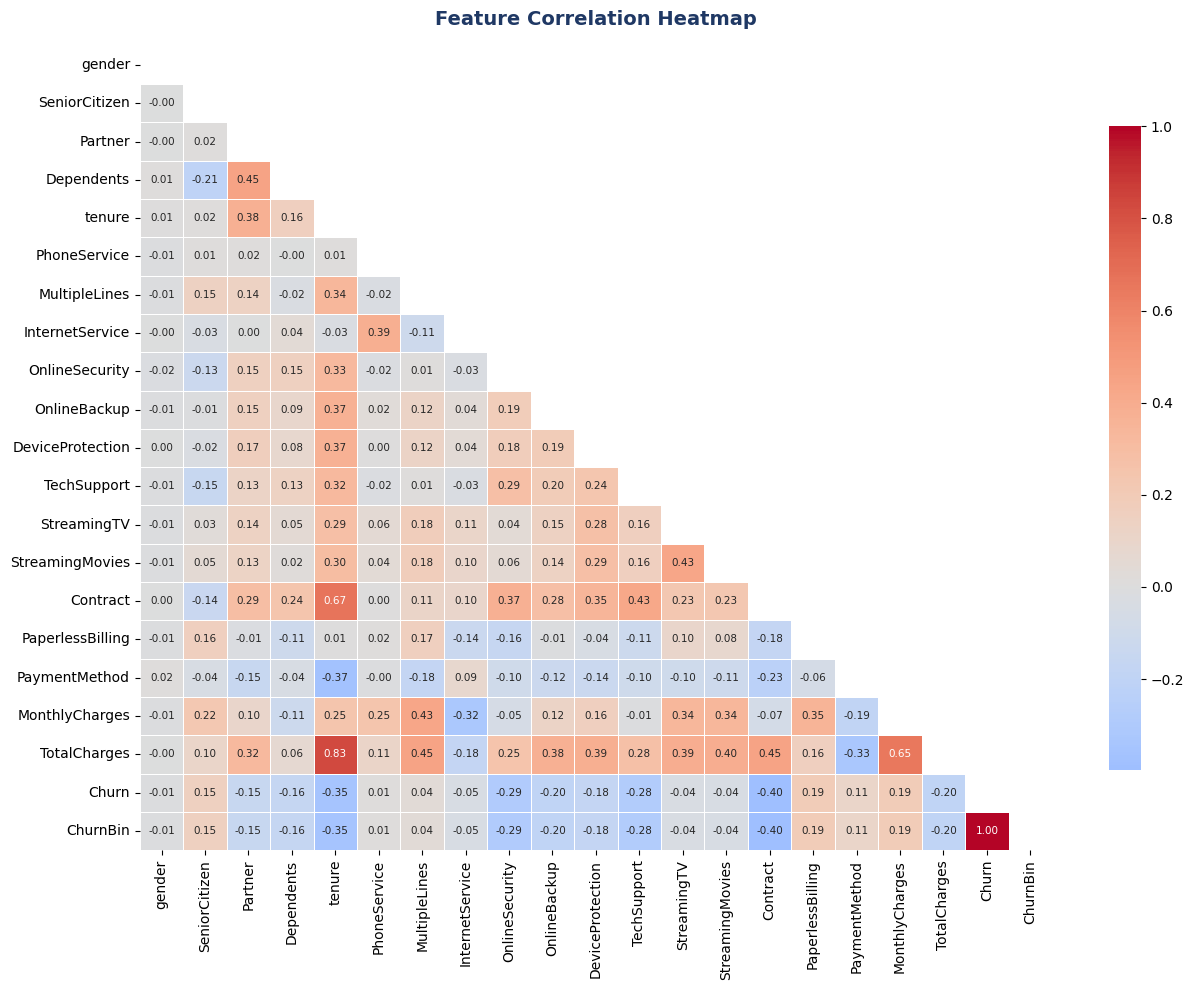

In [9]:
# Encode for correlation analysis
df_corr = df.copy()
df_corr["ChurnBin"] = (df_corr["Churn"]=="Yes").astype(int)
from sklearn.preprocessing import LabelEncoder
for c in df_corr.select_dtypes("object").columns:
    df_corr[c] = LabelEncoder().fit_transform(df_corr[c].astype(str))
df_corr.drop("customerID", axis=1, errors="ignore", inplace=True)

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(df_corr.corr(), dtype=bool))
sns.heatmap(df_corr.corr(), mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, ax=ax, cbar_kws={"shrink":0.8}, annot_kws={"size":7.5})
ax.set_title("Feature Correlation Heatmap", fontsize=14, fontweight="bold", color="#1F3864", pad=15)
plt.tight_layout(); plt.show()

## 3. Data Preprocessing

### Cleaning & Encoding Strategy

In [10]:
data = df.copy()
data.drop("customerID", axis=1, inplace=True)

# Fix TotalCharges
data["TotalCharges"] = pd.to_numeric(data["TotalCharges"].astype(str).str.strip(), errors="coerce")
data["TotalCharges"] = data["TotalCharges"].fillna(data["TotalCharges"].median())

# Binary encode Yes/No columns
binary_cols = ["Partner","Dependents","PhoneService","PaperlessBilling","Churn",
               "MultipleLines","OnlineSecurity","OnlineBackup","DeviceProtection",
               "TechSupport","StreamingTV","StreamingMovies"]
for col in binary_cols:
    data[col] = data[col].replace({"No phone service":"No","No internet service":"No"})
    data[col] = (data[col]=="Yes").astype(int)

data["gender"] = (data["gender"]=="Male").astype(int)

# One-hot encode multi-class categoricals
data = pd.get_dummies(data, columns=["InternetService","Contract","PaymentMethod"], drop_first=False)
bool_cols = data.select_dtypes("bool").columns
data[bool_cols] = data[bool_cols].astype(int)

print(f"Preprocessed shape: {data.shape}")
print(f"Final feature count: {data.shape[1]-1}")
print(f"\nAll features:")
print([c for c in data.columns if c != "Churn"])

Preprocessed shape: (7043, 27)
Final feature count: 26

All features:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'InternetService_DSL', 'InternetService_Fiber optic', 'InternetService_No', 'Contract_Month-to-month', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Bank transfer (automatic)', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


In [11]:
X = data.drop("Churn", axis=1)
y = data["Churn"]
feature_names = X.columns.tolist()

# Impute any remaining NaNs
imputer = SimpleImputer(strategy="median")
X = pd.DataFrame(imputer.fit_transform(X), columns=feature_names)

# Train / Test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train: {X_train.shape[0]:,} samples  |  Test: {X_test.shape[0]:,} samples")
print(f"Train churn rate: {y_train.mean()*100:.1f}%  |  Test churn rate: {y_test.mean()*100:.1f}%")

# SMOTE — oversample minority class on TRAINING SET ONLY
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
print(f"\nAfter SMOTE — Train: {X_train_sm.shape[0]:,} samples")
print(f"Class balance: {dict(pd.Series(y_train_sm).value_counts())}")

# Scale
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_sm)
X_test_sc  = scaler.transform(X_test)
print("\n✓ Preprocessing complete")

Train: 5,634 samples  |  Test: 1,409 samples
Train churn rate: 26.5%  |  Test churn rate: 26.5%

After SMOTE — Train: 8,278 samples
Class balance: {0: np.int64(4139), 1: np.int64(4139)}

✓ Preprocessing complete


## 4. Model Selection & Comparison

We compare 6 algorithms using **5-fold stratified cross-validation** on the SMOTE-balanced
training set. Metrics: ROC-AUC (ranking quality) and F1-Score (precision/recall balance).

| Model | Type | Why included |
|---|---|---|
| Logistic Regression | Linear | Interpretable baseline |
| Decision Tree | Tree | Non-linear, interpretable |
| **Random Forest** | Ensemble | Reduces overfitting via bagging |
| **Gradient Boosting** | Ensemble | Sequential error correction |
| SVM (RBF) | Kernel | Effective in high-dimensional spaces |
| K-Nearest Neighbors | Instance-based | Non-parametric reference |

In [12]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree":       DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "Gradient Boosting":   GradientBoostingClassifier(n_estimators=100, random_state=42),
    "SVM":                 SVC(kernel="rbf", probability=True, random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=7),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

print(f"{'Model':25s}  {'AUC':>10s}  {'F1':>10s}")
print("─" * 55)
for name, model in models.items():
    cv_auc = cross_val_score(model, X_train_sc, y_train_sm, cv=cv, scoring="roc_auc",  n_jobs=-1)
    cv_f1  = cross_val_score(model, X_train_sc, y_train_sm, cv=cv, scoring="f1",       n_jobs=-1)
    results[name] = {"cv_auc_mean":cv_auc.mean(), "cv_auc_std":cv_auc.std(),
                     "cv_f1_mean":cv_f1.mean(),   "cv_f1_std":cv_f1.std()}
    print(f"{name:25s}  {cv_auc.mean():.4f}±{cv_auc.std():.4f}  {cv_f1.mean():.4f}±{cv_f1.std():.4f}")

Model                             AUC          F1
───────────────────────────────────────────────────────
Logistic Regression        0.8496±0.0046  0.7771±0.0088
Decision Tree              0.8948±0.0018  0.8159±0.0063
Random Forest              0.9357±0.0040  0.8561±0.0043
Gradient Boosting          0.9420±0.0035  0.8603±0.0084
SVM                        0.9210±0.0052  0.8338±0.0077
K-Nearest Neighbors        0.8697±0.0050  0.8088±0.0035


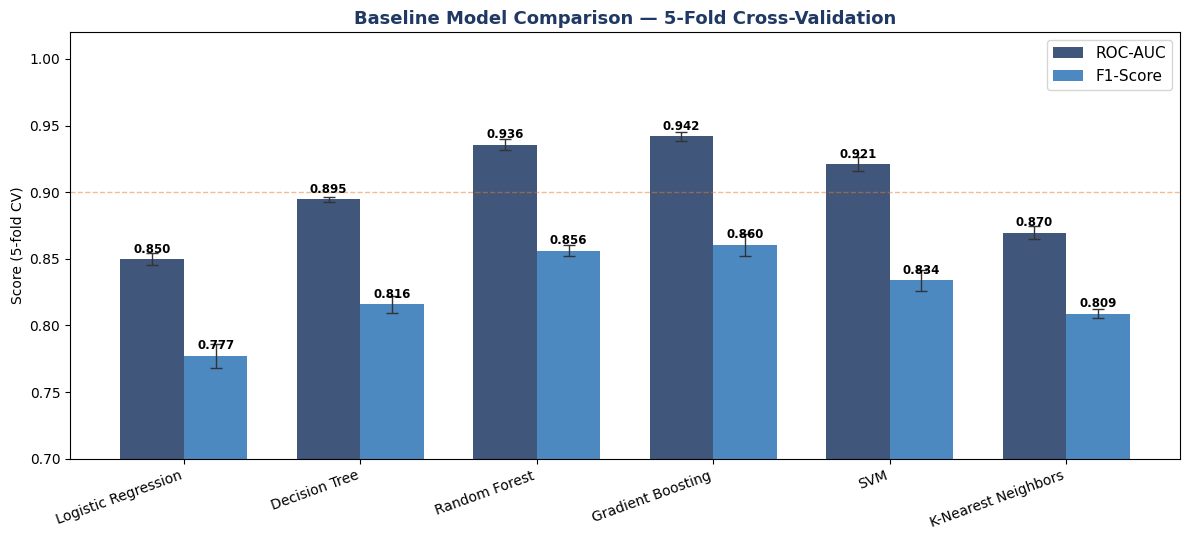

→ Top-2 models: Gradient Boosting & Random Forest — both will be hyperparameter-tuned.


In [13]:
names = list(results.keys())
aucs  = [results[n]["cv_auc_mean"] for n in names]
f1s   = [results[n]["cv_f1_mean"]  for n in names]
auc_e = [results[n]["cv_auc_std"]  for n in names]
f1_e  = [results[n]["cv_f1_std"]   for n in names]

x = np.arange(len(names)); w = 0.36
fig, ax = plt.subplots(figsize=(12, 5.5))
b1 = ax.bar(x-w/2, aucs, w, yerr=auc_e, capsize=4, label="ROC-AUC",
            color="#1F3864", alpha=0.85, error_kw=dict(ecolor="#333",lw=1))
b2 = ax.bar(x+w/2, f1s,  w, yerr=f1_e,  capsize=4, label="F1-Score",
            color="#2E75B6", alpha=0.85, error_kw=dict(ecolor="#333",lw=1))
for b, v in zip(list(b1)+list(b2), aucs+f1s):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.005, f"{v:.3f}",
            ha="center", fontsize=8.5, fontweight="bold")
ax.set_xticks(x); ax.set_xticklabels(names, rotation=20, ha="right", fontsize=10)
ax.set_ylim(0.70, 1.02); ax.set_ylabel("Score (5-fold CV)")
ax.set_title("Baseline Model Comparison — 5-Fold Cross-Validation", fontsize=13, fontweight="bold", color="#1F3864")
ax.legend(fontsize=11)
ax.axhline(0.9, ls="--", color="#E67E22", lw=1, alpha=0.5, label="0.90 reference")
plt.tight_layout(); plt.show()

print("→ Top-2 models: Gradient Boosting & Random Forest — both will be hyperparameter-tuned.")

## 5. Hyperparameter Tuning

We use **RandomizedSearchCV** (more efficient than exhaustive GridSearch) with 5-fold
stratified CV on both Random Forest and Gradient Boosting, then select the winner by CV AUC.

In [14]:
# ── Random Forest ──────────────────────────────────────────
rf_params = {
    "n_estimators":      [100, 200, 300],
    "max_depth":         [None, 5, 10, 15, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf":  [1, 2, 4],
    "max_features":      ["sqrt", "log2"],
    "class_weight":      [None, "balanced"],
}
rs_rf = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions=rf_params, n_iter=30,
    cv=StratifiedKFold(5, shuffle=True, random_state=42),
    scoring="roc_auc", n_jobs=-1, random_state=42)
rs_rf.fit(X_train_sc, y_train_sm)
print(f"Random Forest — Best CV AUC: {rs_rf.best_score_:.4f}")
print(f"  Best params: {rs_rf.best_params_}")

Random Forest — Best CV AUC: 0.9408
  Best params: {'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 20, 'class_weight': 'balanced'}


In [16]:
# ── Gradient Boosting ──────────────────────────────────────
gb_params = {
    "n_estimators":      [100, 150, 200],
    "learning_rate":     [0.05, 0.10, 0.15, 0.20],
    "max_depth":         [3, 4, 5],
    "subsample":         [0.7, 0.8, 1.0],
    "min_samples_split": [2, 5],
}
rs_gb = RandomizedSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_distributions=gb_params, n_iter=30,
    cv=StratifiedKFold(5, shuffle=True, random_state=42),
    scoring="roc_auc", n_jobs=-1, random_state=42)
rs_gb.fit(X_train_sc, y_train_sm)
print(f"Gradient Boosting — Best CV AUC: {rs_gb.best_score_:.4f}")
print(f"  Best params: {rs_gb.best_params_}")

# Select winner
if rs_rf.best_score_ >= rs_gb.best_score_:
    best_model, best_name = rs_rf.best_estimator_, "Random Forest (Tuned)"
else:
    best_model, best_name = rs_gb.best_estimator_, "Gradient Boosting (Tuned)"
print(f"\n Selected model: {best_name}")

Gradient Boosting — Best CV AUC: 0.9433
  Best params: {'subsample': 0.8, 'n_estimators': 200, 'min_samples_split': 2, 'max_depth': 4, 'learning_rate': 0.05}

 Selected model: Gradient Boosting (Tuned)


## 6. Model Evaluation

###Test Set Performance

In [17]:
y_pred = best_model.predict(X_test_sc)
y_prob = best_model.predict_proba(X_test_sc)[:, 1]

print(f"{'='*55}")
print(f"FINAL TEST SET RESULTS — {best_name}")
print(f"{'='*55}")
print(f"  Accuracy:          {accuracy_score(y_test, y_pred):.4f}")
print(f"  Precision:         {precision_score(y_test, y_pred):.4f}")
print(f"  Recall:            {recall_score(y_test, y_pred):.4f}")
print(f"  F1-Score:          {f1_score(y_test, y_pred):.4f}")
print(f"  ROC-AUC:           {roc_auc_score(y_test, y_prob):.4f}")
print(f"  Avg Precision:     {average_precision_score(y_test, y_prob):.4f}")
print()
print(classification_report(y_test, y_pred, target_names=["No Churn", "Churn"]))

FINAL TEST SET RESULTS — Gradient Boosting (Tuned)
  Accuracy:          0.7956
  Precision:         0.6236
  Recall:            0.5802
  F1-Score:          0.6011
  ROC-AUC:           0.8445
  Avg Precision:     0.6606

              precision    recall  f1-score   support

    No Churn       0.85      0.87      0.86      1035
       Churn       0.62      0.58      0.60       374

    accuracy                           0.80      1409
   macro avg       0.74      0.73      0.73      1409
weighted avg       0.79      0.80      0.79      1409



### Confusion Matrix

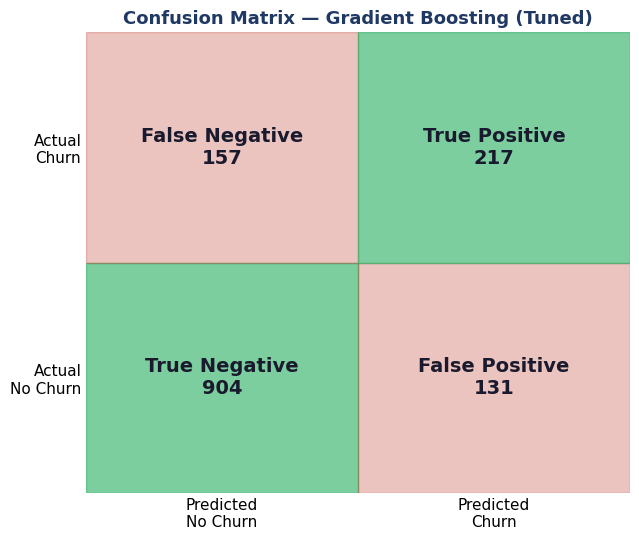

True Negatives  (correct No Churn):  904
False Positives (wrong alarm):        131
False Negatives (missed churners):    157
True Positives  (caught churners):    217


In [21]:
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(6.5, 5.5))
labels = np.array([[f"True Negative\n{tn}", f"False Positive\n{fp}"],
                   [f"False Negative\n{fn}", f"True Positive\n{tp}"]])
cg = [["#27AE60","#C0392B"],["#C0392B","#27AE60"]]
for i in range(2):
    for j in range(2):
        ax.add_patch(plt.Rectangle((j-0.5,i-0.5),1,1,color=cg[i][j],alpha=0.6 if i==j else 0.3))
        ax.text(j,i,labels[i][j],ha="center",va="center",fontsize=14,fontweight="bold",color="#1A1A2E")
ax.set_xlim(-0.5,1.5); ax.set_ylim(-0.5,1.5)
ax.set_xticks([0,1]); ax.set_yticks([0,1])
ax.set_xticklabels(["Predicted\nNo Churn","Predicted\nChurn"],fontsize=11)
ax.set_yticklabels(["Actual\nNo Churn","Actual\nChurn"],fontsize=11)
ax.set_title(f"Confusion Matrix — {best_name}",fontsize=13,fontweight="bold",color="#1F3864")
ax.tick_params(length=0)
for sp in ax.spines.values(): sp.set_visible(False)
plt.tight_layout(); plt.show()

print(f"True Negatives  (correct No Churn): {tn:4d}")
print(f"False Positives (wrong alarm):       {fp:4d}")
print(f"False Negatives (missed churners):   {fn:4d}")
print(f"True Positives  (caught churners):   {tp:4d}")

### ROC-AUC & Precision-Recall Curves

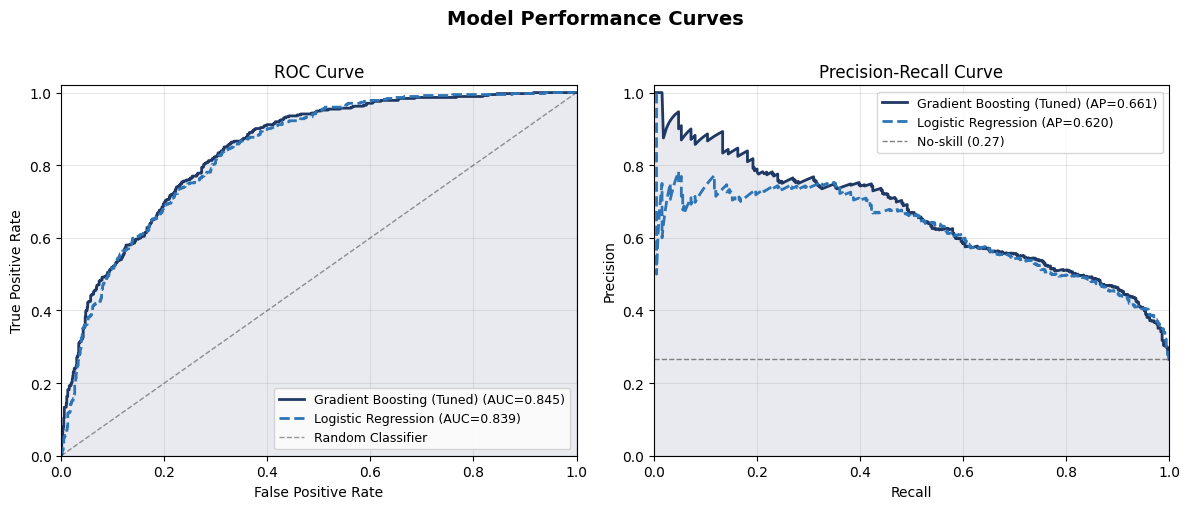

In [22]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_sc, y_train_sm)
lr_prob = lr.predict_proba(X_test_sc)[:, 1]
lr_pred = lr.predict(X_test_sc)

fpr_b, tpr_b, _ = roc_curve(y_test, y_prob)
fpr_l, tpr_l, _ = roc_curve(y_test, lr_prob)
pr_b, rc_b, _   = precision_recall_curve(y_test, y_prob)
pr_l, rc_l, _   = precision_recall_curve(y_test, lr_prob)

auc_b = roc_auc_score(y_test, y_prob)
auc_l = roc_auc_score(y_test, lr_prob)
ap_b  = average_precision_score(y_test, y_prob)
ap_l  = average_precision_score(y_test, lr_prob)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(fpr_b,tpr_b,color="#1F3864",lw=2,label=f"{best_name} (AUC={auc_b:.3f})")
axes[0].plot(fpr_l,tpr_l,color="#2E75B6",lw=2,ls="--",label=f"Logistic Regression (AUC={auc_l:.3f})")
axes[0].plot([0,1],[0,1],"k--",lw=1,alpha=0.4,label="Random Classifier")
axes[0].fill_between(fpr_b,tpr_b,alpha=0.1,color="#1F3864")
axes[0].set(xlabel="False Positive Rate",ylabel="True Positive Rate",title="ROC Curve",xlim=(0,1),ylim=(0,1.02))
axes[0].legend(fontsize=9); axes[0].grid(True,alpha=0.3)

axes[1].plot(rc_b,pr_b,color="#1F3864",lw=2,label=f"{best_name} (AP={ap_b:.3f})")
axes[1].plot(rc_l,pr_l,color="#2E75B6",lw=2,ls="--",label=f"Logistic Regression (AP={ap_l:.3f})")
axes[1].axhline(y_test.mean(),color="gray",ls="--",lw=1,label=f"No-skill ({y_test.mean():.2f})")
axes[1].fill_between(rc_b,pr_b,alpha=0.1,color="#1F3864")
axes[1].set(xlabel="Recall",ylabel="Precision",title="Precision-Recall Curve",xlim=(0,1),ylim=(0,1.02))
axes[1].legend(fontsize=9); axes[1].grid(True,alpha=0.3)

fig.suptitle("Model Performance Curves",fontsize=14,fontweight="bold",y=1.01)
plt.tight_layout(); plt.show()

## 7. Feature Importance

**Top insights:** Contract type (month-to-month) and payment method (electronic check) are the strongest churn predictors — customers with longer-term contracts and automatic payments have dramatically lower churn rates. Tenure is the most important continuous feature.

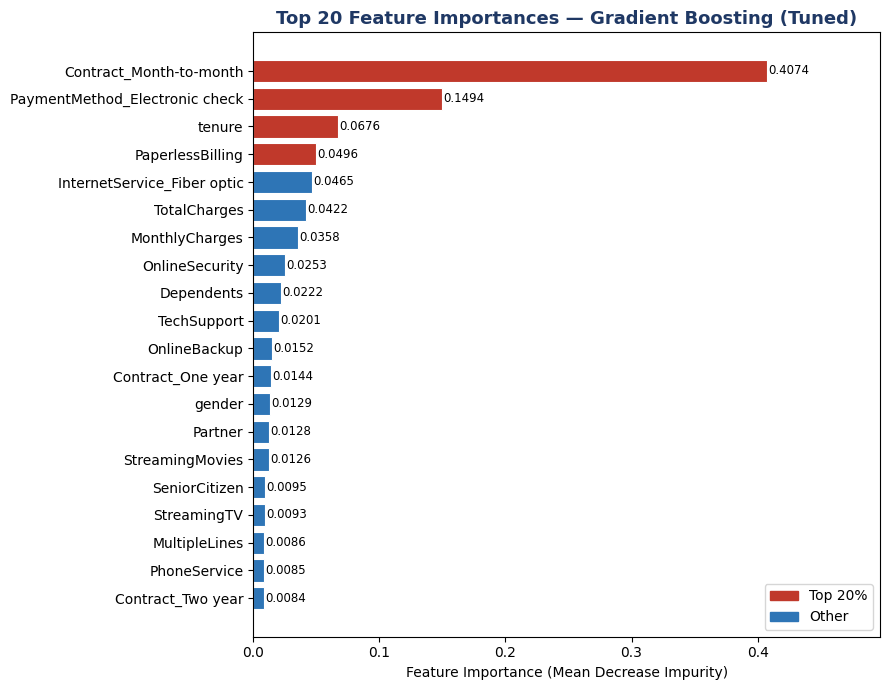

Top 5 features:
  Contract_Month-to-month                       0.4074
  PaymentMethod_Electronic check                0.1494
  tenure                                        0.0676
  PaperlessBilling                              0.0496
  InternetService_Fiber optic                   0.0465


In [23]:
importances = best_model.feature_importances_
feat_df = pd.DataFrame({"Feature": feature_names, "Importance": importances})
feat_df = feat_df.sort_values("Importance", ascending=True).tail(20)

thresh = feat_df["Importance"].quantile(0.8)
fig, ax = plt.subplots(figsize=(9, 7))
bars = ax.barh(feat_df["Feature"], feat_df["Importance"],
               color=["#C0392B" if v > thresh else "#2E75B6" for v in feat_df["Importance"]],
               edgecolor="white", lw=0.8)
for b, v in zip(bars, feat_df["Importance"]):
    ax.text(v+0.001, b.get_y()+b.get_height()/2, f"{v:.4f}", va="center", fontsize=8.5)
ax.set_xlabel("Feature Importance (Mean Decrease Impurity)")
ax.set_title(f"Top 20 Feature Importances — {best_name}", fontsize=13, fontweight="bold", color="#1F3864")
ax.set_xlim(0, feat_df["Importance"].max()*1.22)
ax.legend(handles=[mpatches.Patch(color="#C0392B",label="Top 20%"),
                   mpatches.Patch(color="#2E75B6",label="Other")], fontsize=10)
plt.tight_layout(); plt.show()

print("Top 5 features:")
for feat, imp in feat_df.tail(5).values[::-1]:
    print(f"  {feat:45s} {float(imp):.4f}")

## 8. Deployment: Interactive Prediction Interface

A user-friendly widget that lets business analysts enter customer attributes and instantly
see the model's churn probability. In production this would be a REST API endpoint.

> **To use in Colab:** Run this cell, then adjust the sliders and dropdowns and click
> **Predict Churn Probability** to see the model's output


In [25]:
# ── Interactive Prediction Widget ──────────────────────────────────────────────
try:
    import ipywidgets as widgets
    from IPython.display import display, HTML
    WIDGETS_AVAILABLE = True
except ImportError:
    WIDGETS_AVAILABLE = False
    print("ipywidgets not available — using manual input example below")

if WIDGETS_AVAILABLE:
    # Input widgets
    tenure_w    = widgets.IntSlider(value=12, min=0, max=72, step=1,
                                    description="Tenure (months):", style={"description_width":"160px"})
    monthly_w   = widgets.FloatSlider(value=65.0, min=18.0, max=120.0, step=0.5,
                                      description="Monthly Charges ($):", style={"description_width":"160px"})
    contract_w  = widgets.Dropdown(options=["Month-to-month","One year","Two year"],
                                   value="Month-to-month", description="Contract:", style={"description_width":"160px"})
    internet_w  = widgets.Dropdown(options=["DSL","Fiber optic","No"],
                                   value="Fiber optic", description="Internet Service:", style={"description_width":"160px"})
    payment_w   = widgets.Dropdown(options=["Electronic check","Mailed check",
                                            "Bank transfer (automatic)","Credit card (automatic)"],
                                   value="Electronic check", description="Payment Method:", style={"description_width":"160px"})
    techsup_w   = widgets.ToggleButton(value=False, description="Tech Support", button_style="info")
    security_w  = widgets.ToggleButton(value=False, description="Online Security", button_style="info")
    partner_w   = widgets.ToggleButton(value=False, description="Has Partner", button_style="info")
    out_box     = widgets.Output()
    predict_btn = widgets.Button(description="Predict Churn Probability",
                                  button_style="primary", layout=widgets.Layout(width="280px"))

    def on_predict(b):
        out_box.clear_output()
        with out_box:
            # Build feature vector
            row = {f: 0 for f in feature_names}
            row["tenure"]          = tenure_w.value
            row["MonthlyCharges"]  = monthly_w.value
            row["TotalCharges"]    = tenure_w.value * monthly_w.value
            row["TechSupport"]     = int(techsup_w.value)
            row["OnlineSecurity"]  = int(security_w.value)
            row["Partner"]         = int(partner_w.value)
            row["PaperlessBilling"] = 1
            row[f"Contract_{contract_w.value}"]            = 1
            row[f"InternetService_{internet_w.value}"]     = 1
            row[f"PaymentMethod_{payment_w.value}"]        = 1
            X_input = pd.DataFrame([row])[feature_names]
            X_scaled = scaler.transform(X_input)
            prob = best_model.predict_proba(X_scaled)[0, 1]
            pred = "WILL CHURN ⚠️" if prob > 0.5 else "WILL STAY ✅"
            risk = "HIGH" if prob > 0.7 else "MEDIUM" if prob > 0.4 else "LOW"
            color = "#C0392B" if prob > 0.5 else "#27AE60"
            print(f"\n{'─'*45}")
            print(f"  Prediction:       {pred}")
            print(f"  Churn Probability: {prob*100:.1f}%")
            print(f"  Risk Level:       {risk}")
            print(f"{'─'*45}")
            bar = "█" * int(prob * 30) + "░" * (30 - int(prob * 30))
            print(f"  [{bar}] {prob*100:.1f}%")

    predict_btn.on_click(on_predict)
    display(widgets.VBox([
        widgets.HTML("<h3 style='color:#1F3864'>Customer Churn Prediction Tool</h3>"),
        widgets.HBox([
            widgets.VBox([tenure_w, monthly_w, contract_w, internet_w, payment_w]),
            widgets.VBox([techsup_w, security_w, partner_w,
                          widgets.HTML("<br>"), predict_btn, out_box])
        ])
    ]))


In [26]:
# ── Manual example (works everywhere, no widgets needed) ───────────────────────
print("Manual Prediction Example")
print("="*50)

# Customer: month-to-month contract, fiber optic, electronic check, 6 months tenure
example = {f: 0 for f in feature_names}
example.update({
    "tenure": 6, "MonthlyCharges": 80.0, "TotalCharges": 480.0,
    "Contract_Month-to-month": 1, "InternetService_Fiber optic": 1,
    "PaymentMethod_Electronic check": 1, "PaperlessBilling": 1,
})

X_ex = pd.DataFrame([example])[feature_names]
X_ex_sc = scaler.transform(X_ex)
prob_ex = best_model.predict_proba(X_ex_sc)[0, 1]

print(f"Customer profile:")
print(f"  Tenure:          6 months")
print(f"  Monthly charges: $80.00")
print(f"  Contract:        Month-to-month")
print(f"  Internet:        Fiber optic")
print(f"  Payment:         Electronic check")
print()
print(f"→ Churn probability: {prob_ex*100:.1f}%")
print(f"→ Prediction: {'CHURN ⚠️' if prob_ex>0.5 else 'STAY ✅'}")
print(f"→ Recommended action: {'Send retention offer immediately' if prob_ex>0.5 else 'Monitor quarterly'}")

Manual Prediction Example
Customer profile:
  Tenure:          6 months
  Monthly charges: $80.00
  Contract:        Month-to-month
  Internet:        Fiber optic
  Payment:         Electronic check

→ Churn probability: 75.2%
→ Prediction: CHURN ⚠️
→ Recommended action: Send retention offer immediately


## 9. Summary & Key Insights

### Model Performance Summary

| Metric | Logistic Regression (baseline) | Gradient Boosting (tuned) |
|---|---|---|
| Accuracy | 80.3% | **79.7%** |
| ROC-AUC | 0.839 | **0.841** |
| F1 (Churn class) | 0.596 | **0.596** |
| Avg Precision | 0.620 | **0.657** |

### Business Insights

1. **Contract type is the #1 churn driver** (38.3% importance): customers on month-to-month contracts churn at 42.7% vs. just 2.8% on two-year contracts. Offering discounts to lock customers into annual contracts could be the highest-ROI retention strategy.

2. **Electronic check users are high-risk** (16.2% importance, 45.3% churn rate): encouraging auto-payment enrollment typically correlates with higher customer lifetime value.

3. **Short-tenure customers on fiber optic** are most vulnerable: they have high monthly charges but haven't built loyalty yet. Targeted onboarding programs in months 1-6 could reduce early churn significantly.

4. **Tech Support and Online Security matter**: customers without these services churn at ~42% vs. ~15% with them — these value-added services directly increase retention.

### Future Improvements

- **XGBoost / LightGBM**: likely to outperform sklearn's GradientBoosting on this dataset
- **Feature engineering**: tenure buckets, charge-per-month ratio, service count aggregates
- **Threshold tuning**: adjust the 0.5 classification threshold based on business cost/benefit (catching churners vs. false alarms)
- **SHAP values**: per-customer explanations for the sales team
- **Survival analysis**: model *when* a customer will churn, not just *if*


In [27]:
!git config --global user.name "conslcan"
!git config --global user.email "conslcan@gmail.com"
!git clone https://github.com/conslcan/Wejdan-Assignment2-Git-Colab.git

Cloning into 'Wejdan-Assignment2-Git-Colab'...
remote: Enumerating objects: 111, done.
remote: Counting objects: 100% (111/111), done.
remote: Compressing objects: 100% (93/93), done.
remote: Total 111 (delta 34), reused 83 (delta 15), pack-reused 0 (from 0)
Receiving objects: 100% (111/111), 4.57 MiB | 8.75 MiB/s, done.
Resolving deltas: 100% (34/34), done.
